<a href="https://colab.research.google.com/github/Omarzcode/CNN/blob/main/diget_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


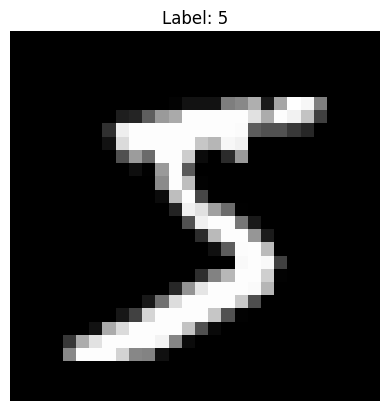

In [ ]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [ ]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
print(X_train[0].min())
print(X_train[0].max())

0.0
1.0


In [ ]:
print(X_train.shape)

(60000, 28, 28)


In [ ]:
X_train = X_train[..., None]
X_test = X_test[..., None]

In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9575 - loss: 0.1356 - val_accuracy: 0.9855 - val_loss: 0.0472
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9860 - loss: 0.0439 - val_accuracy: 0.9888 - val_loss: 0.0383
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 84s 28ms/step - accuracy: 0.9901 - loss: 0.0297 - val_accuracy: 0.9873 - val_loss: 0.0441
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9934 - loss: 0.0212 - val_accuracy: 0.9892 - val_loss: 0.0370
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9946 - loss: 0.0162 - val_accuracy: 0.9918 - val_loss: 0.0318


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9907 - loss: 0.0283
Test accuracy: 0.9907000064849854
Test loss: 0.02834310010075569


In [ ]:
image = X_test[0]

prediction = model.predict(image.reshape(1, 28, 28, 1))

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[[2.7686524e-09 1.5067092e-09 1.2162413e-07 3.5729940e-07 1.4299853e-10
  6.9050099e-10 2.4326702e-12 9.9999940e-01 4.3329954e-10 1.6320647e-07]]


In [ ]:
predicted_digit = prediction.argmax()

print("Predicted:", predicted_digit)
print("Actual:", y_test[0])

Predicted: 7
Actual: 7


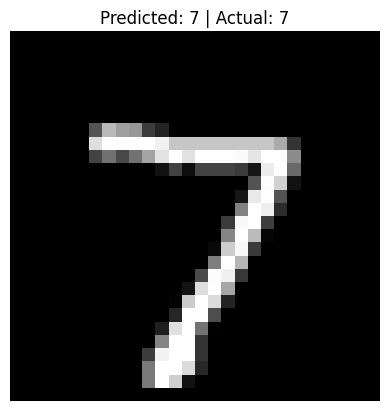

In [ ]:
plt.imshow(X_test[0].squeeze(), cmap="gray")
plt.title(f"Predicted: {predicted_digit} | Actual: {y_test[0]}")
plt.axis("off")
plt.show()

In [ ]:
image = X_test[0]

prediction = model.predict(image.reshape(1, 28, 28, 1), verbose=0)[0]

for digit, probability in enumerate(prediction):
    print(f"{digit}: {probability:.6f}")

0: 0.000000
1: 0.000000
2: 0.000000
3: 0.000000
4: 0.000000
5: 0.000000
6: 0.000000
7: 0.999999
8: 0.000000
9: 0.000000


In [ ]:
conv1 = model.layers[0]

In [ ]:
filters, biases = conv1.get_weights()

print("Filters shape:", filters.shape)
print("Biases shape:", biases.shape)

Filters shape: (3, 3, 1, 32)
Biases shape: (32,)


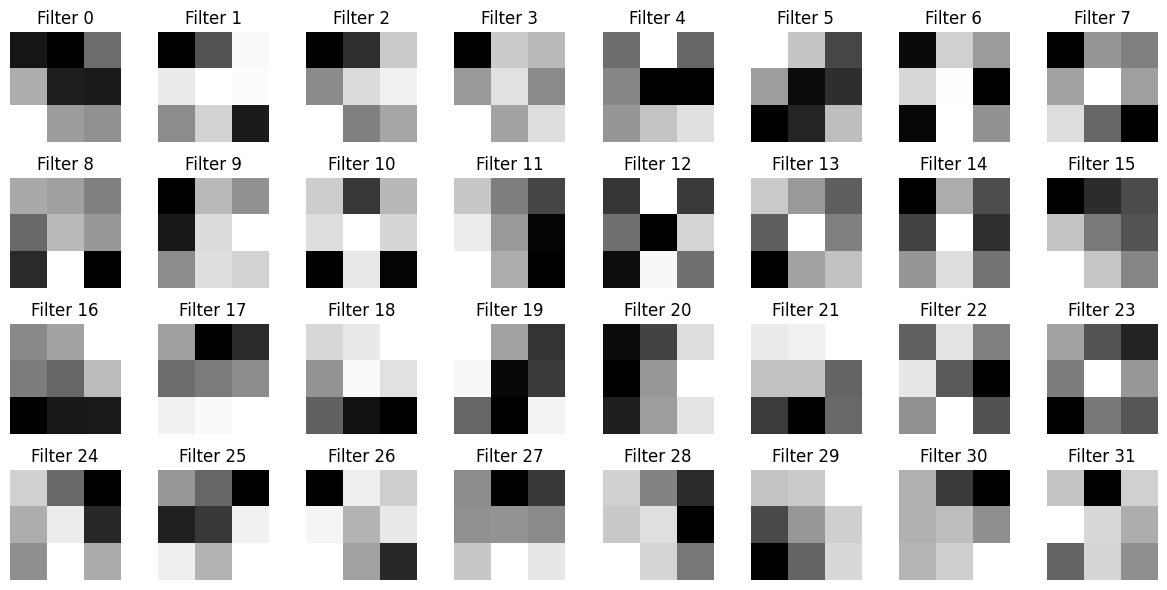

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(filters[:, :, 0, i], cmap="gray")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image = X_test[0]

In [ ]:
activation_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

In [ ]:
image = X_test[0]

activations = activation_model.predict(
    image.reshape(1, 28, 28, 1),
    verbose=0
)

print(activations.shape)

(1, 26, 26, 32)


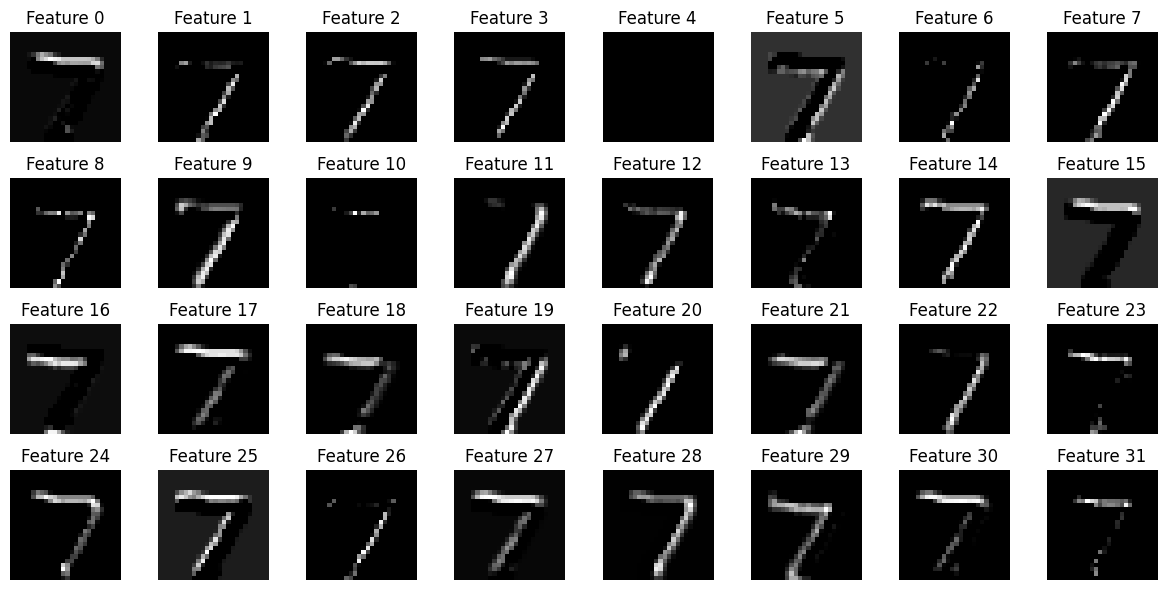

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(activations[0, :, :, i], cmap="gray")
    ax.set_title(f"Feature {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
conv2 = model.layers[2]

filters2, biases2 = conv2.get_weights()

print("Filters shape:", filters2.shape)
print("Biases shape:", biases2.shape)

Filters shape: (3, 3, 32, 64)
Biases shape: (64,)


In [ ]:
activation_model_2 = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[2].output
)

In [ ]:
activations2 = activation_model_2.predict(
    X_test[0].reshape(1, 28, 28, 1),
    verbose=0
)

print(activations2.shape)

(1, 11, 11, 64)


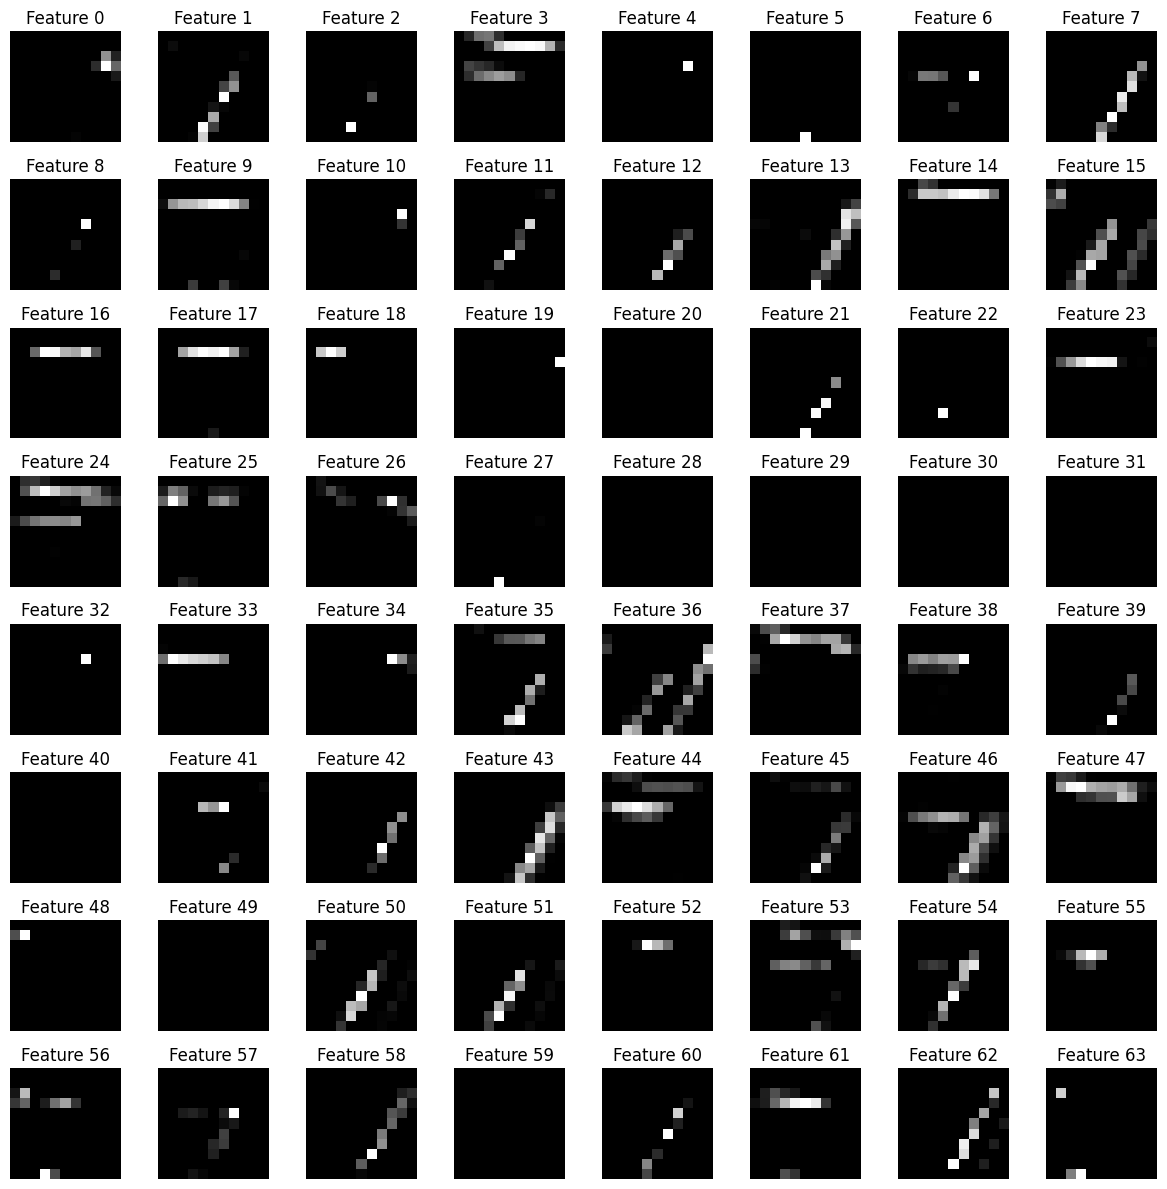

In [ ]:
fig, axes = plt.subplots(8, 8, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    ax.imshow(activations2[0, :, :, i], cmap="gray")
    ax.set_title(f"Feature {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
predictions = model.predict(X_test, verbose=0)
predicted_digits = predictions.argmax(axis=1)

wrong = predicted_digits != y_test

print("Wrong predictions:", wrong.sum())

Wrong predictions: 93


In [ ]:
import numpy as np

wrong_indices = np.where(wrong)[0]

print(wrong_indices[:20])

[ 321  326  340  359  582  659  674  720  882  947 1014 1226 1232 1247
 1260 1319 1364 1393 1530 1681]


In [ ]:
idx = wrong_indices[0]

print("Actual:", y_test[idx])
print("Predicted:", predicted_digits[idx])

Actual: 2
Predicted: 7


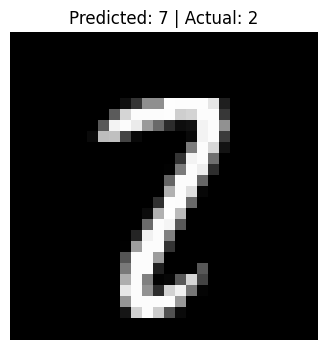

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(X_test[idx].squeeze(), cmap="gray")
plt.title(
    f"Predicted: {predicted_digits[idx]} | Actual: {y_test[idx]}"
)
plt.axis("off")
plt.show()

In [ ]:
for digit, probability in enumerate(predictions[idx]):
    print(f"{digit}: {probability:.6f}")

0: 0.000053
1: 0.000017
2: 0.446056
3: 0.000038
4: 0.000000
5: 0.000000
6: 0.000000
7: 0.553797
8: 0.000018
9: 0.000021


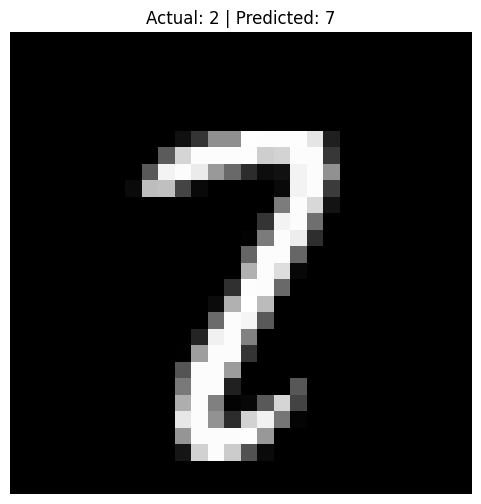

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(X_test[idx].squeeze(), cmap="gray")

plt.title(
    f"Actual: {y_test[idx]} | Predicted: {predicted_digits[idx]}"
)

plt.axis("off")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, predicted_digits)

print(cm)

[[ 975    1    0    0    0    0    1    2    1    0]
 [   3 1125    1    2    0    0    2    1    0    1]
 [   1    1 1027    0    0    0    0    3    0    0]
 [   0    0    0 1008    0    1    0    1    0    0]
 [   0    0    0    0  980    0    0    1    0    1]
 [   1    0    1   11    0  874    4    0    0    1]
 [   2    2    0    0    2    1  950    0    1    0]
 [   0    2    7    0    0    0    0 1018    0    1]
 [   1    0    3    4    0    1    1    1  961    2]
 [   1    1    0    1    3    4    0    7    3  989]]


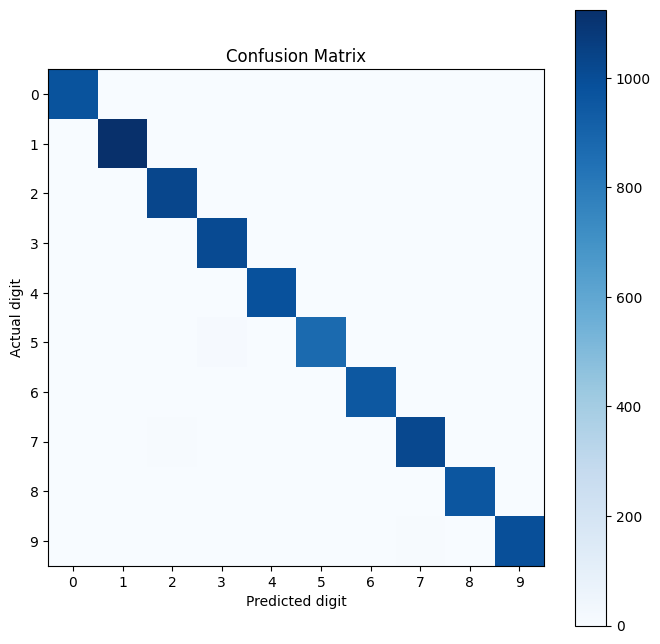

In [ ]:
plt.figure(figsize=(8, 8))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.xlabel("Predicted digit")
plt.ylabel("Actual digit")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
five_as_three = np.where(
    (y_test == 5) & (predicted_digits == 3)
)[0]

print("Number of 5 → 3 mistakes:", len(five_as_three))

Number of 5 → 3 mistakes: 11


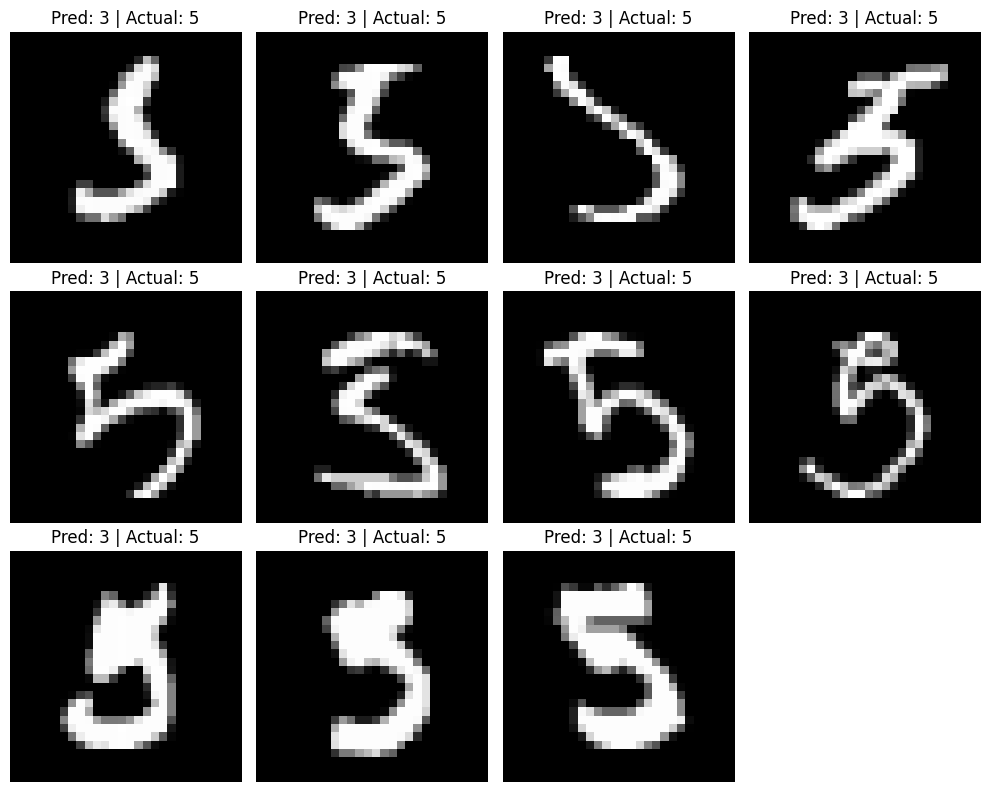

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax in axes.flat:
    ax.axis("off")

for ax, idx in zip(axes.flat, five_as_three):
    ax.imshow(X_test[idx].squeeze(), cmap="gray")
    ax.set_title(f"Pred: 3 | Actual: 5")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
idx = 0

image = X_test[idx]

print("Actual digit:", y_test[idx])

Actual digit: 7


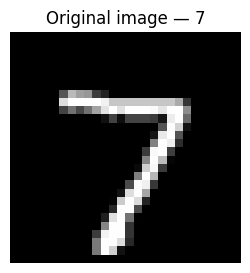

In [ ]:
plt.figure(figsize=(3, 3))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Original image — {y_test[idx]}")
plt.axis("off")
plt.show()

In [ ]:
layer_outputs = [
    model.layers[0].output,  # Conv1
    model.layers[1].output,  # Pool1
    model.layers[2].output,  # Conv2
    model.layers[3].output   # Pool2
]

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=layer_outputs
)

In [ ]:
outputs = feature_model.predict(
    image.reshape(1, 28, 28, 1),
    verbose=0
)

In [ ]:
for i, output in enumerate(outputs):
    print(i, output.shape)

0 (1, 26, 26, 32)
1 (1, 13, 13, 32)
2 (1, 11, 11, 64)
3 (1, 5, 5, 64)


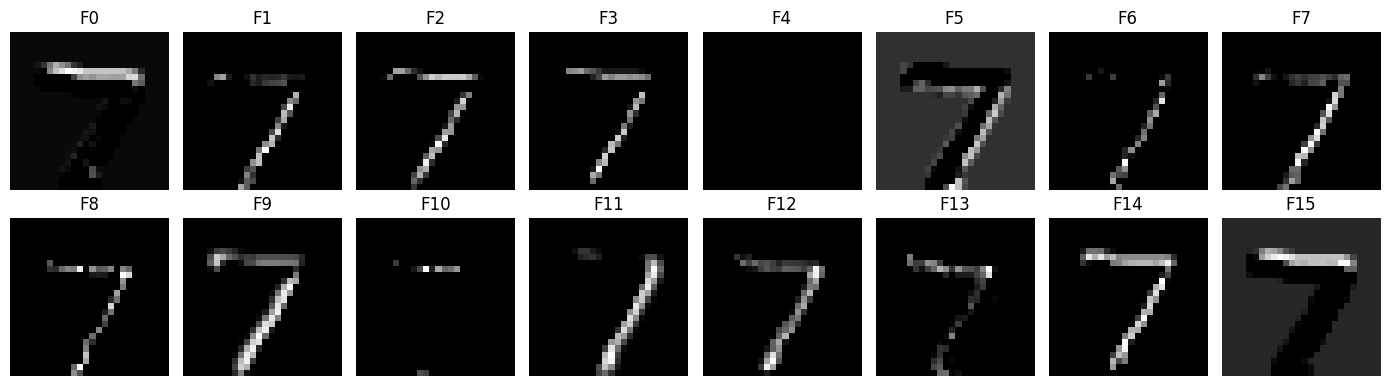

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(outputs[0][0, :, :, i], cmap="gray")
    ax.set_title(f"F{i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

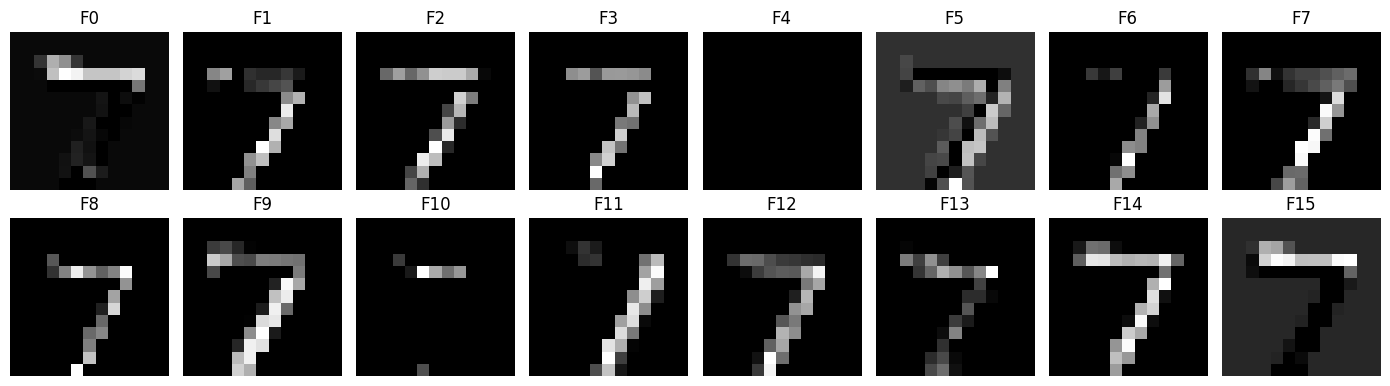

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(outputs[1][0, :, :, i], cmap="gray")
    ax.set_title(f"F{i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

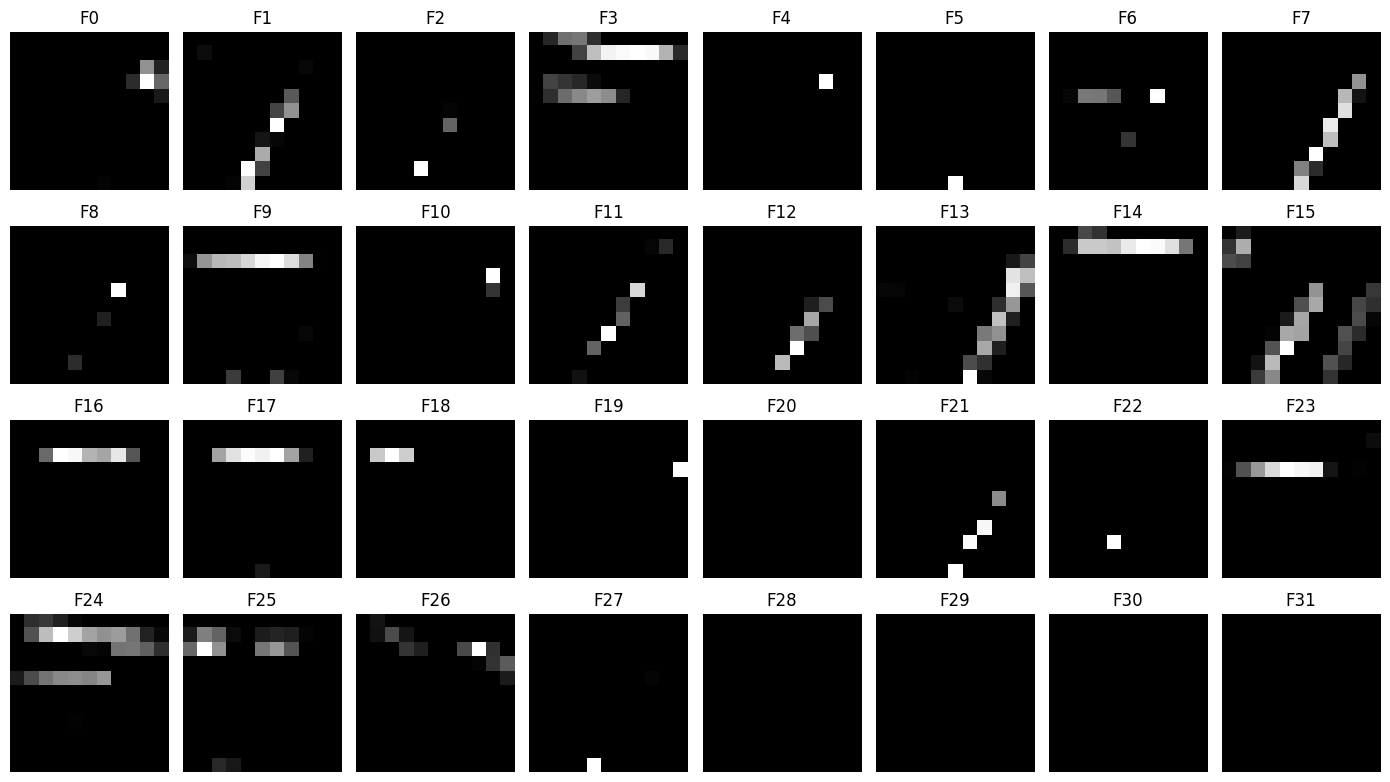

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(14, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(outputs[2][0, :, :, i], cmap="gray")
    ax.set_title(f"F{i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

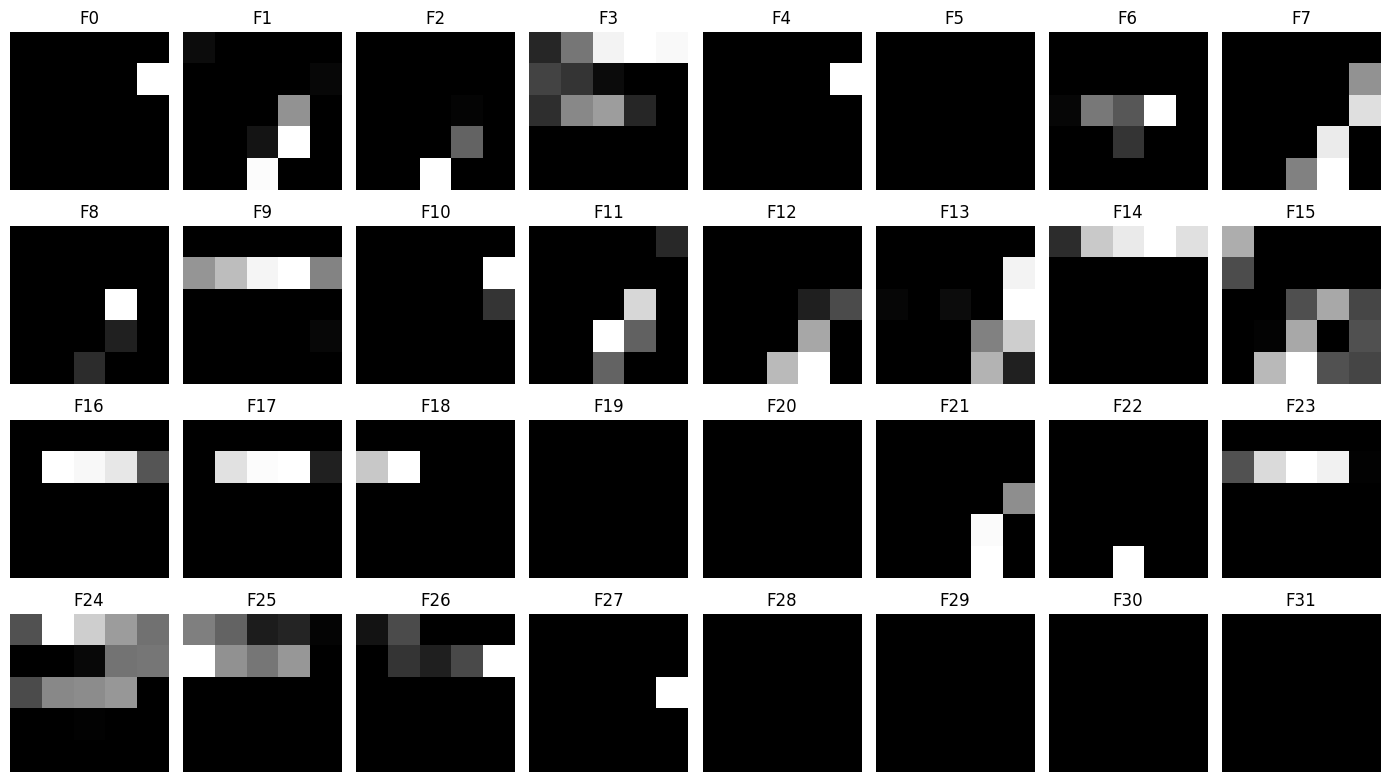

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(14, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(outputs[3][0, :, :, i], cmap="gray")
    ax.set_title(f"F{i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Original canvas shape: (280, 280)


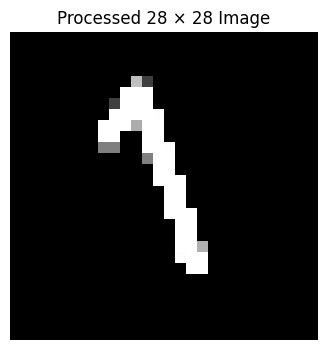

CNN input shape: (1, 28, 28, 1)

        CNN PREDICTION
Predicted digit: 1
Confidence: 95.47%

Probabilities:
0: 0.00%
1: 95.47%
2: 3.53%
3: 0.49%
4: 0.04%
5: 0.00%
6: 0.01%
7: 0.07%
8: 0.39%
9: 0.00%


In [ ]:
# ============================================================
# MNIST CNN - REAL MOUSE DRAWING CANVAS FOR GOOGLE COLAB
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display, HTML
from google.colab import output
import base64
from PIL import Image
import io


# ============================================================
# 1. SHOW DRAWING CANVAS
# ============================================================

html = """
<div style="text-align:center; font-family:Arial;">

<h2>🧠 Draw a digit for the CNN</h2>

<canvas id="digitCanvas"
        width="280"
        height="280"
        style="
            border:3px solid white;
            background:black;
            cursor:crosshair;
            touch-action:none;
        ">
</canvas>

<br><br>

<button id="clearButton"
        style="
            font-size:18px;
            padding:10px 30px;
            margin-right:10px;
            background:#f44336;
            color:white;
            border:none;
            border-radius:5px;
        ">
    Clear
</button>

<button id="predictButton"
        style="
            font-size:18px;
            padding:10px 30px;
            background:#4CAF50;
            color:white;
            border:none;
            border-radius:5px;
        ">
    Predict
</button>

<br><br>

<div id="status" style="font-size:20px;">
    Draw a digit and click Predict
</div>

</div>
"""

display(HTML(html))


# ============================================================
# 2. JAVASCRIPT DRAWING
# ============================================================

js = """
(async () => {

    const canvas = document.getElementById("digitCanvas");
    const ctx = canvas.getContext("2d");

    const clearButton = document.getElementById("clearButton");
    const predictButton = document.getElementById("predictButton");
    const status = document.getElementById("status");

    // Black background
    ctx.fillStyle = "black";
    ctx.fillRect(0, 0, canvas.width, canvas.height);

    // White brush
    ctx.strokeStyle = "white";
    ctx.lineWidth = 22;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";

    let drawing = false;

    function getPosition(event) {

        const rect = canvas.getBoundingClientRect();

        return {
            x: (event.clientX - rect.left)
                * canvas.width / rect.width,

            y: (event.clientY - rect.top)
                * canvas.height / rect.height
        };
    }

    canvas.addEventListener("pointerdown", function(event) {

        drawing = true;

        const pos = getPosition(event);

        ctx.beginPath();
        ctx.moveTo(pos.x, pos.y);

        event.preventDefault();
    });

    canvas.addEventListener("pointermove", function(event) {

        if (!drawing) return;

        const pos = getPosition(event);

        ctx.lineTo(pos.x, pos.y);
        ctx.stroke();

        event.preventDefault();
    });

    canvas.addEventListener("pointerup", function(event) {

        drawing = false;
        ctx.beginPath();

        event.preventDefault();
    });

    canvas.addEventListener("pointerleave", function() {

        drawing = false;
        ctx.beginPath();
    });


    // Clear button
    clearButton.onclick = function() {

        ctx.fillStyle = "black";
        ctx.fillRect(0, 0, canvas.width, canvas.height);

        ctx.strokeStyle = "white";

        status.innerText = "Draw a digit and click Predict";
    };


    // Wait for Predict
    return await new Promise((resolve) => {

        predictButton.onclick = function() {

            status.innerText = "⏳ Processing...";

            const image = canvas.toDataURL("image/png");

            resolve(image);
        };

    });

})()
"""

# Wait until you click Predict
image_data = output.eval_js(js)


# ============================================================
# 3. CONVERT CANVAS IMAGE TO NUMPY
# ============================================================

header, encoded = image_data.split(",", 1)

image_bytes = base64.b64decode(encoded)

image = Image.open(
    io.BytesIO(image_bytes)
).convert("L")

image = np.array(image)


print("Original canvas shape:", image.shape)


# ============================================================
# 4. RESIZE 280×280 → 28×28
# ============================================================

image_resized = tf.image.resize(
    image[..., np.newaxis],
    (28, 28)
).numpy().squeeze()


# ============================================================
# 5. NORMALIZE
# ============================================================

image_resized = image_resized.astype("float32") / 255.0


# ============================================================
# 6. SHOW WHAT THE CNN ACTUALLY RECEIVES
# ============================================================

plt.figure(figsize=(4, 4))

plt.imshow(
    image_resized,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("Processed 28 × 28 Image")

plt.axis("off")

plt.show()


# ============================================================
# 7. PREPARE INPUT FOR CNN
# ============================================================

model_input = image_resized.reshape(
    1,
    28,
    28,
    1
)

print("CNN input shape:", model_input.shape)


# ============================================================
# 8. PREDICT
# ============================================================

probabilities = model.predict(
    model_input,
    verbose=0
)[0]

predicted_digit = np.argmax(probabilities)

confidence = probabilities[predicted_digit]


# ============================================================
# 9. DISPLAY RESULT
# ============================================================

print()
print("================================")
print("        CNN PREDICTION")
print("================================")

print(
    f"Predicted digit: {predicted_digit}"
)

print(
    f"Confidence: {confidence * 100:.2f}%"
)

print()
print("Probabilities:")

for digit, probability in enumerate(probabilities):

    print(
        f"{digit}: {probability * 100:.2f}%"
    )